In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import random
from scipy import stats

import os
import pickle
import cvxpy as cp
from tqdm import tqdm
import seaborn as sns

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

import functions

import matplotlib.ticker as ticker

In [2]:
# load old results

with open("results_080726.pkl", "rb") as f:
    results1 = pickle.load(f)

with open("results_180726.pkl", "rb") as f:
    results2 = pickle.load(f)

results_old = results1 + results2

In [3]:
with open("results_260726.pkl", "rb") as f:
    results = pickle.load(f)

# Main results

# Performance

600 results: 10 seeds × 12 months × 5 gammas

What fraction of portfolios have CVaR exactly at the constraint?
gamma
0.00    0.900000
0.25    0.900000
0.50    0.900000
0.75    0.891667
1.00    0.908333
Name: cvar_binding, dtype: float64
Distribution of CVaR:


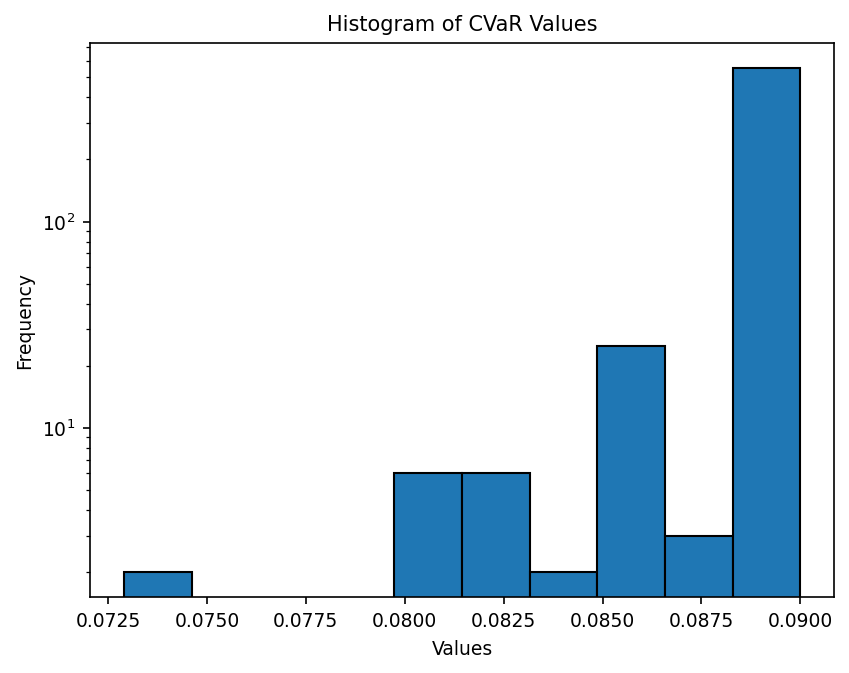

       cum_return     mdd  ret_cvar_ratio  mean_regret  mean_mse
gamma                                                           
0.00       0.0478  0.1039          0.0507       0.0453    0.0087
0.25       0.0479  0.1057          0.0515       0.0453    0.0087
0.50       0.0466  0.1069          0.0500       0.0454    0.0087
0.75       0.0429  0.1093          0.0475       0.0456    0.0087
1.00       0.0438  0.1074          0.0478       0.0456    0.0087
=== Table 1: Performance Metrics ===
            Cum. Return (↑)  Return/CVaR (↑)          MDD (↓)       Regret (↓)            MSE (↓)
γ                                                                                                
γ=0 (MSE)   0.0478 ± 0.1053  0.0507 ± 0.0880  0.1039 ± 0.0355  0.0453 ± 0.0088  0.00871 ± 0.00102
γ=0.25      0.0479 ± 0.0980  0.0515 ± 0.0829  0.1057 ± 0.0349  0.0453 ± 0.0090  0.00867 ± 0.00102
γ=0.5       0.0466 ± 0.1028  0.0500 ± 0.0856  0.1069 ± 0.0360  0.0454 ± 0.0098  0.00873 ± 0.00095
γ=0.75      0.0429

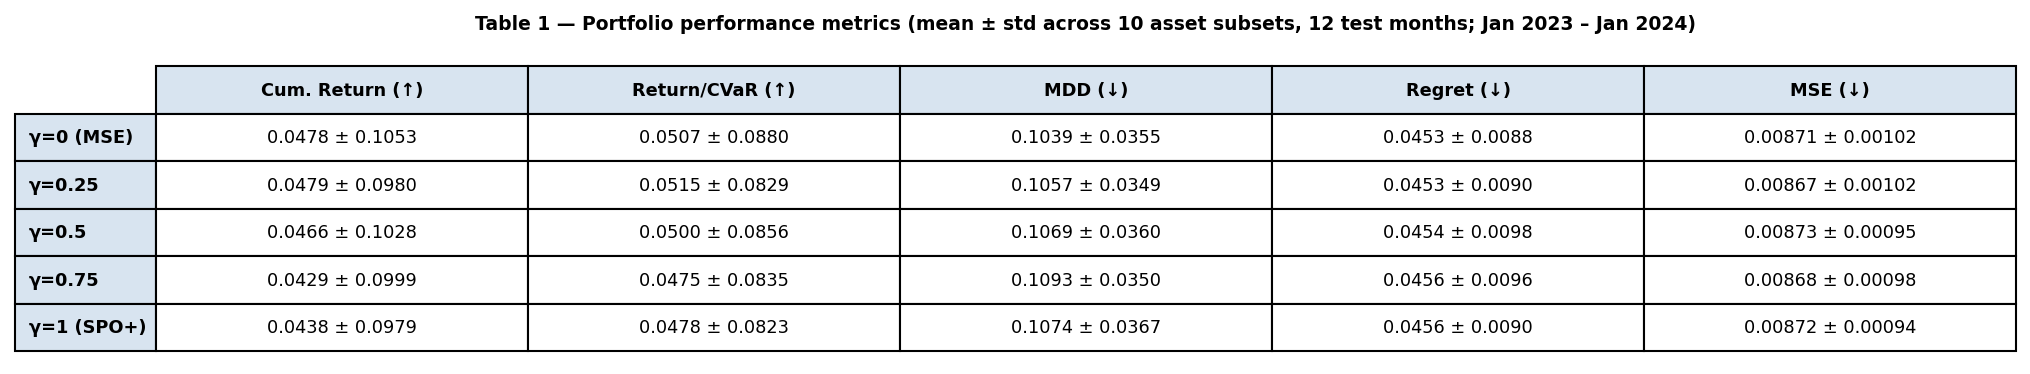

=== Per-subset regret breakdown ===
           γ=0 (MSE)  γ=0.25   γ=0.5  γ=0.75  γ=1 (SPO+)      Best γ
Subset 1      0.0397  0.0419  0.0401  0.0409      0.0413   γ=0 (MSE)
Subset 2      0.0533  0.0539  0.0543  0.0537      0.0550   γ=0 (MSE)
Subset 3      0.0493  0.0487  0.0475  0.0475      0.0480       γ=0.5
Subset 4      0.0482  0.0468  0.0514  0.0532      0.0500      γ=0.25
Subset 5      0.0407  0.0396  0.0403  0.0408      0.0410      γ=0.25
Subset 6      0.0435  0.0422  0.0390  0.0398      0.0400       γ=0.5
Subset 7      0.0467  0.0471  0.0470  0.0448      0.0478      γ=0.75
Subset 8      0.0507  0.0504  0.0524  0.0524      0.0526      γ=0.25
Subset 9      0.0561  0.0571  0.0574  0.0578      0.0546  γ=1 (SPO+)
Subset 10     0.0251  0.0249  0.0243  0.0250      0.0254       γ=0.5
Mean          0.0453  0.0453  0.0454  0.0456      0.0456      γ=0.25


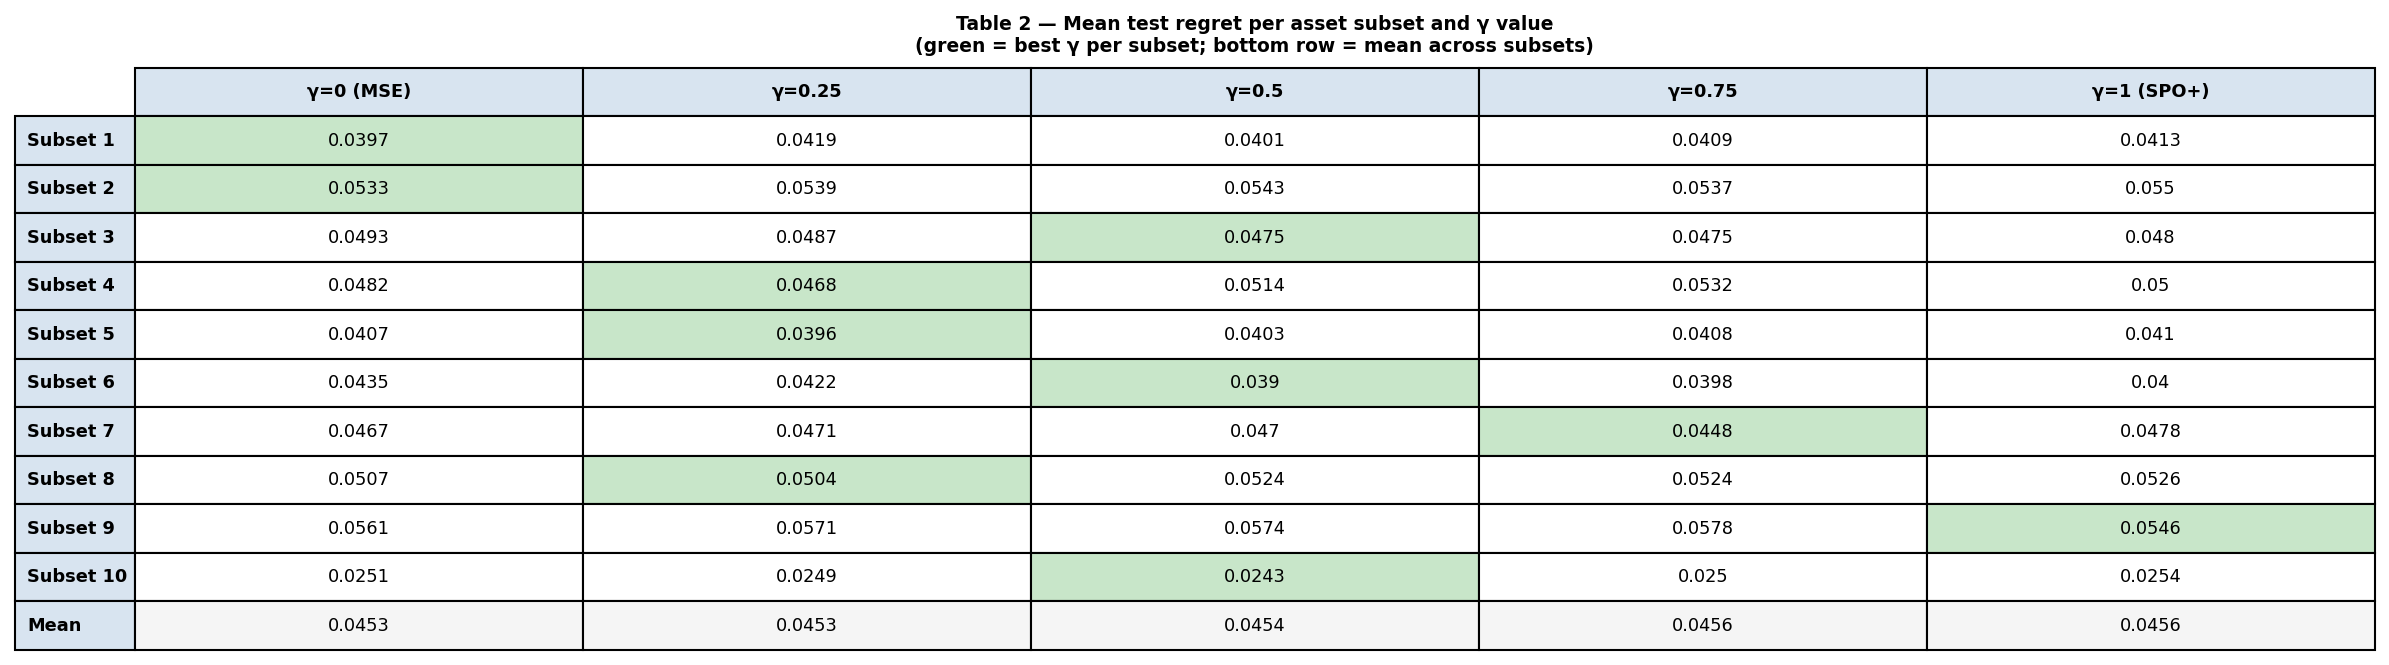

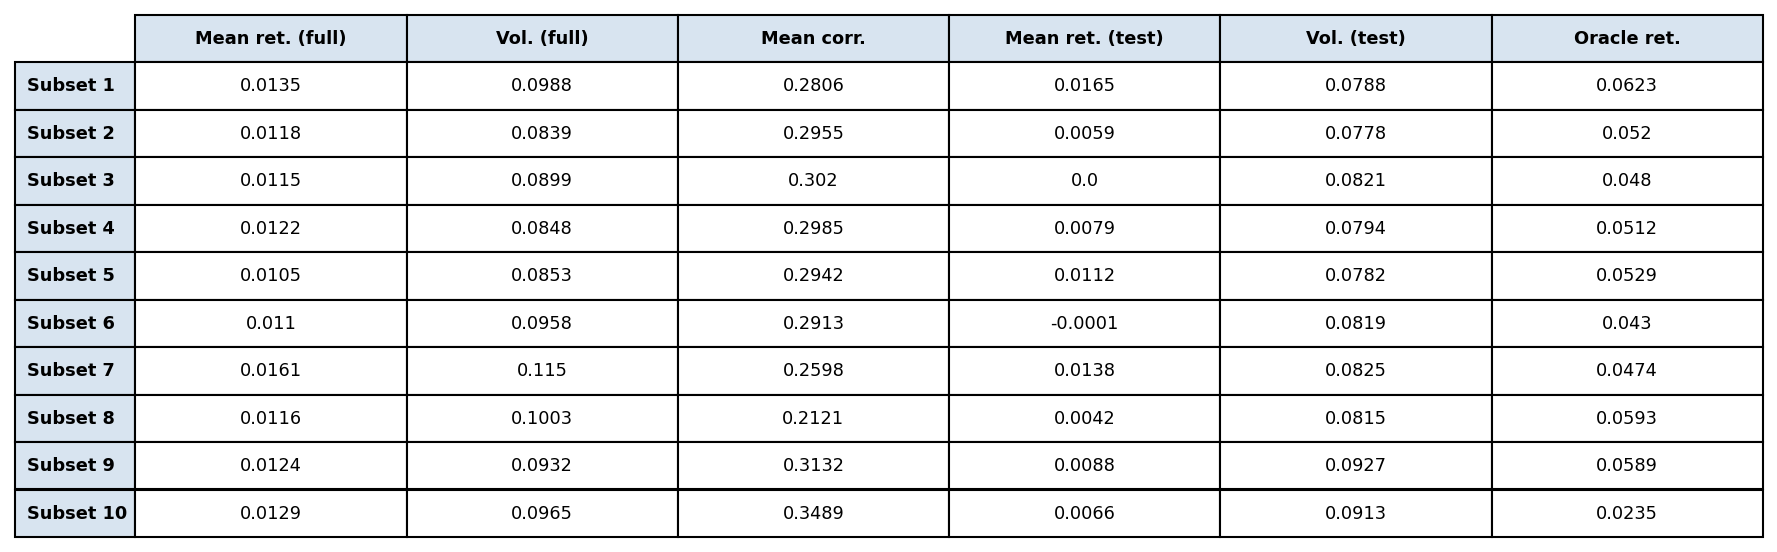

In [7]:
# Constants

ALPHA      = 0.95
GAMMAS     = [0.0, 0.25, 0.5, 0.75, 1.0]
GLABELS    = {0.0:  'γ=0 (MSE)', 0.25: 'γ=0.25', 0.5: 'γ=0.5',
              0.75: 'γ=0.75',    1.0:  'γ=1 (SPO+)'}
GSHORT     = {g: f'γ={g}' for g in GAMMAS}
COLORS     = {0.0: '#0072B2', 0.25: '#56B4E9', 0.5: '#009E73',
              0.75: '#E69F00', 1.0: '#D55E00'}
ACTIVE_TOL = 1e-4

plt.rcParams.update({
    'font.size': 9, 'axes.titlesize': 10,
    'axes.labelsize': 9, 'figure.dpi': 150,
})

# subsets saved during experiment
subsets = {
    seed: pd.read_csv(f"../data/processed/return_matrix_random_seed{seed}.csv")
    for seed in range(1, 11)
}

# Pre-compute test scenario matrices (120 unique: 10 seeds × 12 months)

sm_cache = {}
for r in results:
    key = (r['data_seed'], r['test_index'])
    if key not in sm_cache:
        sm_cache[key] = functions.get_scenario_loss_matrix(
            subsets[r['data_seed']],
            r['test_index'],
            num_scenarios=1000,
            random_seed=42
        )

def portfolio_cvar(weights, sm, alpha=ALPHA):
    losses   = sm @ weights
    sorted_l = np.sort(losses)
    k        = int(np.ceil(alpha * len(sorted_l)))
    raw      = float(sorted_l[k:].mean())
    return round(raw, 4)
 
# Build main dataframe

rows = []
for r in results:
    sm = sm_cache[(r['data_seed'], r['test_index'])]
    w  = r['weights']
    rows.append({
        'data_seed':       r['data_seed'],
        'gamma':           r['gamma'],
        'test_index':      r['test_index'],
        'realized_return': r['realized_return'],
        'oracle_return':   r['oracle_return'],
        'test_regret':     r['test_regret'],
        'test_mse':        r['test_mse'],
        'weights':         w,
        'Y_hat_test':      r['Y_hat_test'],
        'Y_test':          r['Y_test'],
        'best_epoch':      r['best_epoch'],
        'realized_cvar':   portfolio_cvar(w, sm),
        'n_active':        int(np.sum(np.abs(w) > ACTIVE_TOL)),
        'active_mask':     tuple((np.abs(w) > ACTIVE_TOL).astype(int)),
    })

df = pd.DataFrame(rows)
print(f"{len(df)} results: {df['data_seed'].nunique()} seeds × "
      f"{df['test_index'].nunique()} months × {df['gamma'].nunique()} gammas\n")

# What fraction of portfolios have CVaR at the constraint?
df['cvar_binding'] = df['realized_cvar'].apply(
    lambda c: abs(c - 0.09) < 1e-4
)
print("What fraction of portfolios have CVaR exactly at the constraint?")
print(df.groupby('gamma')['cvar_binding'].mean())

print("Distribution of CVaR:")
df['realized_cvar'].plot(kind='hist', edgecolor='black')
plt.title('Histogram of CVaR Values')
plt.xlabel('Values')
plt.ylabel('Frequency')
# plt.ylim(0, 20)
plt.yscale('log')
plt.show()

# Per-seed time-series metrics
# Aggregate 12 monthly returns per (data_seed, gamma) in chronological order
# (higher test_index = earlier calendar date → sort descending)

seed_rows = []

for seed in range(1, 11):
    for g in GAMMAS:

        # Select (seed, gamma) combination
        mask = (df['data_seed'] == seed) & (df['gamma'] == g)
        sub  = df[mask].copy()

        # Sort by calendar date: test_index=12 is earliest, test_index=1 is latest
        # Descending test_index = chronological (oldest to newest)
        sub = sub.sort_values('test_index', ascending=False)

        # Monthly returns and CVaRs as arrays in chronological order
        monthly_returns = sub['realized_return'].values   
        monthly_cvars   = sub['realized_cvar'].values     

        # Cumulative wealth
        # Compound each month: start with 1, multiply by (1 + r) each month
        wealth_path    = np.cumprod(1 + monthly_returns)
        final_wealth   = float(wealth_path[-1])           
        cumulative_ret = final_wealth - 1                

        # Maximum Drawdown
        # At each point, how far below the previous peak are we?
        # running_peak: highest wealth achieved so far
        # drawdown:     (current - peak) / peak  (always smaller than 0)
        # MDD:          the most negative drawdown (reported as positive)
        running_peak   = np.maximum.accumulate(wealth_path)
        drawdown_path  = (wealth_path - running_peak) / running_peak
        mdd            = float(-drawdown_path.min())     

        # Return / CVaR ratio
        # Sharpe ratio analogue: mean monthly return divided by mean monthly CVaR
        # CVaR is positive (it's a loss measure, so > 0 when binding)
        mean_return    = float(monthly_returns.mean())
        mean_cvar      = float(monthly_cvars.mean())
        ret_cvar_ratio = mean_return / mean_cvar

        seed_rows.append({
            'data_seed':      seed,
            'gamma':          g,
            'cum_return':     cumulative_ret,
            'mdd':            mdd,
            'ret_cvar_ratio': ret_cvar_ratio,
            'mean_regret':    float(sub['test_regret'].mean()),
            'mean_mse':       float(sub['test_mse'].mean()),
        })

sm_df = pd.DataFrame(seed_rows)

# Sanity check: each (seed, gamma) should have exactly 12 monthly observations
assert all(
    len(df[(df['data_seed'] == s) & (df['gamma'] == g)]) == 12
    for s in range(1, 6) for g in GAMMAS
), "Some (seed, gamma) pairs have != 12 months"

print(sm_df.groupby('gamma')[['cum_return','mdd','ret_cvar_ratio',
                               'mean_regret','mean_mse']].mean().round(4))


# Performance metrics table

def fmt(series, dec=3):
    return f"{series.mean():.{dec}f} ± {series.std():.{dec}f}"

tbl_rows = []
cols_def = [
    ('Cum. Return (↑)',  'cum_return',     4),
    ('Return/CVaR (↑)', 'ret_cvar_ratio',  4),
    ('MDD (↓)',          'mdd',             4),
    ('Regret (↓)',       'mean_regret',     4),
    ('MSE (↓)',          'mean_mse',        5),
]

for g in GAMMAS:
    sub = sm_df[sm_df['gamma'] == g]
    row = {'γ': GLABELS[g]}
    for col_name, col_key, dec in cols_def:
        row[col_name] = fmt(sub[col_key], dec)
    tbl_rows.append(row)

tbl = pd.DataFrame(tbl_rows).set_index('γ')
print("=== Table 1: Performance Metrics ===")
print(tbl.to_string())
print()

fig, ax = plt.subplots(figsize=(16, 2.6))
ax.axis('off')
t = ax.table(
    cellText  = tbl.values,
    colLabels = tbl.columns,
    rowLabels = tbl.index,
    cellLoc   = 'center',
    loc       = 'center',
)
t.auto_set_font_size(False)
t.set_fontsize(8.5)
t.scale(1, 1.9)
for (row, col), cell in t.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#D8E4F0')
ax.set_title(
    'Table 1 — Portfolio performance metrics (mean ± std across 10 asset subsets, '
    '12 test months; Jan 2023 – Jan 2024)',
    fontsize=9, fontweight='bold', pad=14,
)
plt.savefig('final_performance_table.pdf', bbox_inches='tight')
plt.show()

# Per-seed regret breakdown table
# Shows regret for every (subset, gamma) combination
# Reveals heterogeneity

pivot = sm_df.pivot(index='data_seed', columns='gamma', values='mean_regret')
pivot.columns = [GLABELS[g] for g in GAMMAS]
pivot.index   = [f'Subset {s}' for s in pivot.index]

# Add mean and best-gamma column
pivot.loc['Mean'] = pivot.mean()
pivot['Best γ']   = pivot[list(GLABELS.values())].idxmin(axis=1)

print("=== Per-subset regret breakdown ===")
print(pivot.round(4).to_string())

# Plot as table

# Values to display (regret only, no Best γ column in the figure)
display_cols  = [GLABELS[g] for g in GAMMAS]
display_data  = pivot[display_cols].copy()

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.axis('off')

t = ax.table(
    cellText  = display_data.round(4).values,
    colLabels = display_data.columns,
    rowLabels = display_data.index,
    cellLoc   = 'center',
    loc       = 'center',
)
t.auto_set_font_size(False)
t.set_fontsize(8.5)
t.scale(1, 1.9)

# Style header and index
for (row, col), cell in t.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#D8E4F0')

# Highlight minimum regret per row (best gamma per subset)
n_rows = len(display_data)
for i in range(n_rows):
    row_vals = display_data.iloc[i].values.astype(float)
    best_col = int(np.argmin(row_vals))
    t[i + 1, best_col].set_facecolor('#C8E6C9')   # light green = best

# Shade the Mean row differently
for col in range(len(display_cols)):
    t[n_rows, col].set_facecolor('#F5F5F5')

ax.set_title(
    'Table 2 — Mean test regret per asset subset and γ value\n'
    '(green = best γ per subset; bottom row = mean across subsets)',
    fontsize=9,
    fontweight='bold',
    pad=20,          # increase distance from the axes
)

plt.tight_layout()
plt.savefig('final_regret_per_seed_table.pdf', bbox_inches='tight')
plt.show()

# Asset subset characterization

char_rows = []

for seed in range(1, 11):
    ret_mat   = subsets[seed].values          # shape (289, 15), all monthly returns
    full_ret  = ret_mat                       # full history for long-run character
    test_ret  = ret_mat[-12:, :]              # last 12 months = test period

    corr_matrix = np.corrcoef(full_ret.T)     # (15, 15)
    off_diag    = ~np.eye(15, dtype=bool)

    oracle_sub  = df[(df['data_seed'] == seed) & (df['gamma'] == 0.0)]

    char_rows.append({
        'Subset':            f'Subset {seed}',
        'Mean ret. (full)':  round(float(full_ret.mean()), 4),
        'Vol. (full)':       round(float(full_ret.std()),  4),
        'Mean corr.':        round(float(corr_matrix[off_diag].mean()), 4),
        'Mean ret. (test)':  round(float(test_ret.mean()), 4),
        'Vol. (test)':       round(float(test_ret.std()),  4),
        'Oracle ret.':       round(float(oracle_sub['oracle_return'].mean()), 4),
    })

char_df = pd.DataFrame(char_rows).set_index('Subset')

fig, ax = plt.subplots(figsize=(14, 2.4))
ax.axis('off')
t = ax.table(
    cellText  = char_df.values,
    colLabels = char_df.columns,
    rowLabels = char_df.index,
    cellLoc   = 'center',
    loc       = 'center',
)
t.auto_set_font_size(False)
t.set_fontsize(8.5)
t.scale(1, 1.9)
for (row, col), cell in t.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#D8E4F0')
plt.savefig('final_subset_characteristics_table.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Statistical test: does any gamma != 0 outperform gamma = 0 (pure MSE)?

# For each performance metric (cumulative return, Return/CVaR ratio, MDD,
# mean regret, mean MSE), compares the 10 seed-level observations at
# gamma=0 against the same 10 seeds at each of gamma in
# {0.25, 0.5, 0.75, 1.0}, using a paired Wilcoxon signed-rank test
# (n=10, non-parametric, robust to the small sample size and to
# non-normal differences).

# H0 (per gamma, per metric): no difference between gamma and gamma=0.
# Reported: mean difference (gamma - gamma=0) and the raw Wilcoxon p-value.

# cum_return, ret_cvar_ratio: higher is better -> positive diff = improvement
# mdd, mean_regret, mean_mse: lower is better  -> negative diff = improvement

METRICS = ['cum_return', 'ret_cvar_ratio', 'mdd', 'mean_regret', 'mean_mse']
GAMMAS_TO_TEST = [0.25, 0.5, 0.75, 1.0]

for metric in METRICS:
    pivot_m = sm_df.pivot(index='data_seed', columns='gamma', values=metric)
    g0 = pivot_m[0.0].values

    print(f"\n{metric}")
    for g in GAMMAS_TO_TEST:
        g_vals = pivot_m[g].values
        diff = np.mean(g_vals - g0)
        w_p = stats.wilcoxon(g_vals, g0).pvalue
        print(f"  γ={g}: diff={diff:+.4f}, p={w_p:.4f}")


cum_return
  γ=0.25: diff=+0.0001, p=0.6953
  γ=0.5: diff=-0.0012, p=0.6953
  γ=0.75: diff=-0.0048, p=0.5566
  γ=1.0: diff=-0.0040, p=0.4316

ret_cvar_ratio
  γ=0.25: diff=+0.0008, p=0.7695
  γ=0.5: diff=-0.0007, p=0.6953
  γ=0.75: diff=-0.0032, p=0.7695
  γ=1.0: diff=-0.0029, p=0.4316

mdd
  γ=0.25: diff=+0.0017, p=0.9219
  γ=0.5: diff=+0.0029, p=0.3750
  γ=0.75: diff=+0.0053, p=0.1934
  γ=1.0: diff=+0.0034, p=0.0645

mean_regret
  γ=0.25: diff=-0.0001, p=0.7695
  γ=0.5: diff=+0.0000, p=0.7695
  γ=0.75: diff=+0.0003, p=0.8457
  γ=1.0: diff=+0.0002, p=0.4316

mean_mse
  γ=0.25: diff=-0.0000, p=1.0000
  γ=0.5: diff=+0.0000, p=0.9219
  γ=0.75: diff=-0.0000, p=0.6250
  γ=1.0: diff=+0.0000, p=0.9219


## MSE / Regret Trade Off

In [6]:
from scipy.stats import wilcoxon, ttest_rel
piv = sm_df.pivot(index='data_seed', columns='gamma', values='mean_regret')
print(ttest_rel(piv[0.0], piv[1.0]))
print(wilcoxon(piv[0.0], piv[1.0]))

TtestResult(statistic=np.float64(-0.43423072170352783), pvalue=np.float64(0.6743449756234433), df=np.int64(9))
WilcoxonResult(statistic=np.float64(19.0), pvalue=np.float64(0.431640625))


In [7]:
from scipy.stats import spearmanr, wilcoxon

# --- Per-seed Spearman correlations across the 5 gamma values ---
corr_rows = []
for seed in range(1, 11):
    sub = sm_df[sm_df['data_seed'] == seed].sort_values('gamma')
    rho_gamma_mse,    p_gamma_mse    = spearmanr(sub['gamma'], sub['mean_mse'])
    rho_gamma_regret, p_gamma_regret = spearmanr(sub['gamma'], sub['mean_regret'])
    rho_mse_regret,   p_mse_regret   = spearmanr(sub['mean_mse'], sub['mean_regret'])
    corr_rows.append({
        'data_seed':        seed,
        'rho(gamma, mse)':    rho_gamma_mse,
        'rho(gamma, regret)': rho_gamma_regret,
        'rho(mse, regret)':   rho_mse_regret,
    })

corr_df = pd.DataFrame(corr_rows).set_index('data_seed')
print("=== Per-seed Spearman rank correlations across gamma ===")
print(corr_df.round(3).to_string())
print()

# --- Aggregate: how consistent is the trade-off direction across seeds? ---
print("=== Summary across 10 seeds ===")
print(corr_df.mean().round(3).rename('mean rho'))
print()
print("Fraction of seeds with rho(gamma, mse) > 0:   ",
      (corr_df['rho(gamma, mse)'] > 0).mean())
print("Fraction of seeds with rho(gamma, regret) < 0:",
      (corr_df['rho(gamma, regret)'] < 0).mean())
print("Fraction of seeds with rho(mse, regret) < 0:  ",
      (corr_df['rho(mse, regret)'] < 0).mean())
print()

# --- Test whether the mean rho is significantly different from 0 across seeds ---
# (one-sample Wilcoxon signed-rank test on the per-seed rho values)
for col in corr_df.columns:
    stat, p = wilcoxon(corr_df[col])
    print(f"Wilcoxon signed-rank test for {col} != 0: statistic={stat:.3f}, p={p:.4f}")

=== Per-seed Spearman rank correlations across gamma ===
           rho(gamma, mse)  rho(gamma, regret)  rho(mse, regret)
data_seed                                                       
1                      0.8                 0.4              -0.1
2                     -0.1                 0.7              -0.1
3                     -0.8                -0.6               0.4
4                      0.2                 0.6              -0.6
5                      1.0                 0.7               0.7
6                      0.7                -0.6               0.1
7                     -0.9                 0.3               0.1
8                      0.4                 0.9               0.3
9                     -1.0                 0.0               0.0
10                     1.0                 0.3               0.3

=== Summary across 10 seeds ===
rho(gamma, mse)       0.13
rho(gamma, regret)    0.27
rho(mse, regret)      0.11
Name: mean rho, dtype: float64

Fraction of seeds

C:\Users\maxiw\AppData\Local\Temp\ipykernel_19140\2503469407.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
C:\Users\maxiw\AppData\Local\Temp\ipykernel_19140\2503469407.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


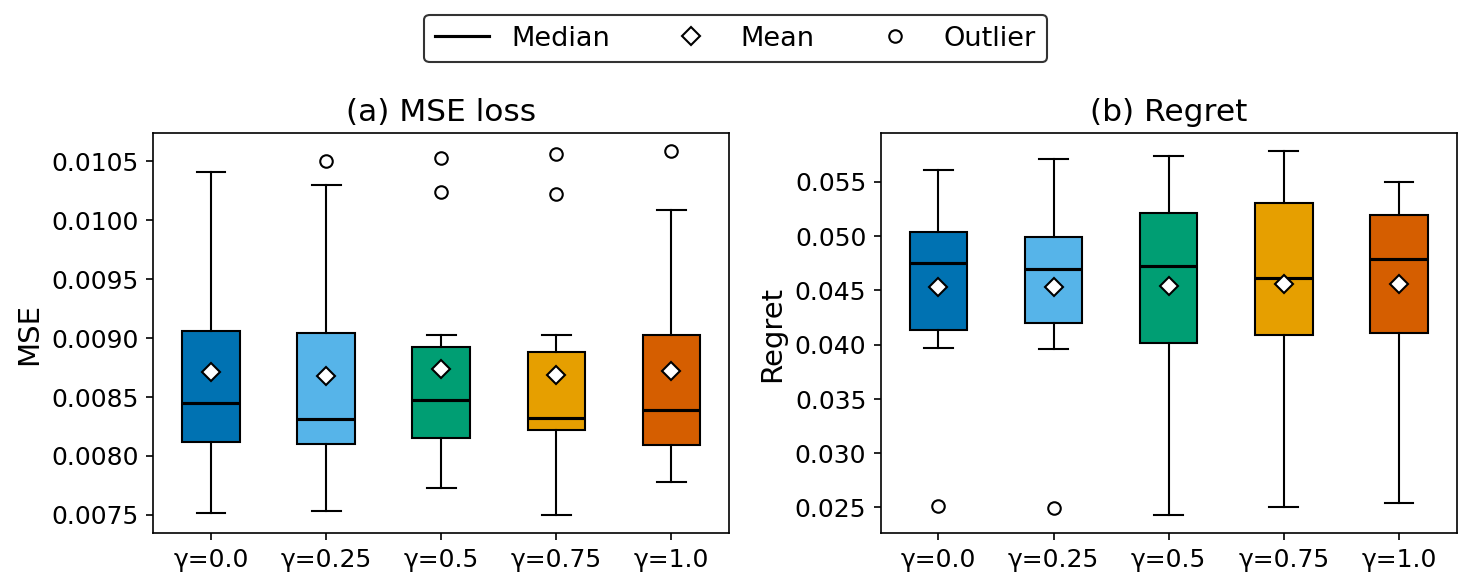

In [33]:
# FIGURE 2 (replicated): MSE and Regret boxplots per gamma, distribution across data seeds

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 13})  # bump global font size for this figure

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- (a) MSE boxplot ---
mse_data = [sm_df.loc[sm_df['gamma'] == g, 'mean_mse'].values for g in GAMMAS]
bp1 = axes[0].boxplot(
    mse_data, labels=[GSHORT[g] for g in GAMMAS], patch_artist=True,
    showmeans=True,
    medianprops=dict(color='black', linewidth=1.5),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=6),
)
for patch, g in zip(bp1['boxes'], GAMMAS):
    patch.set_facecolor(COLORS[g])
# axes[0].set_yscale('log')
axes[0].set_ylabel('MSE', fontsize=14)
axes[0].set_title('(a) MSE loss', fontsize=15)
axes[0].tick_params(axis='both', labelsize=12)

# --- (b) Regret boxplot ---
regret_data = [sm_df.loc[sm_df['gamma'] == g, 'mean_regret'].values for g in GAMMAS]
bp2 = axes[1].boxplot(
    regret_data, labels=[GSHORT[g] for g in GAMMAS], patch_artist=True,
    showmeans=True,
    medianprops=dict(color='black', linewidth=1.5),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=6),
)
for patch, g in zip(bp2['boxes'], GAMMAS):
    patch.set_facecolor(COLORS[g])
axes[1].set_ylabel('Regret', fontsize=14)
axes[1].set_title('(b) Regret', fontsize=15)
axes[1].tick_params(axis='both', labelsize=12)

# --- Shared legend for median vs. mean vs. outlier ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1.5, label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markersize=6, label='Outlier'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.0), frameon=True, edgecolor='black', fontsize=13)

plt.tight_layout()
fig.subplots_adjust(top=0.78)
plt.savefig('final_mse_regret_boxplots.pdf', bbox_inches='tight')
plt.show()

## Portfolio Concentration

C:\Users\maxiw\AppData\Local\Temp\ipykernel_19140\2590627159.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


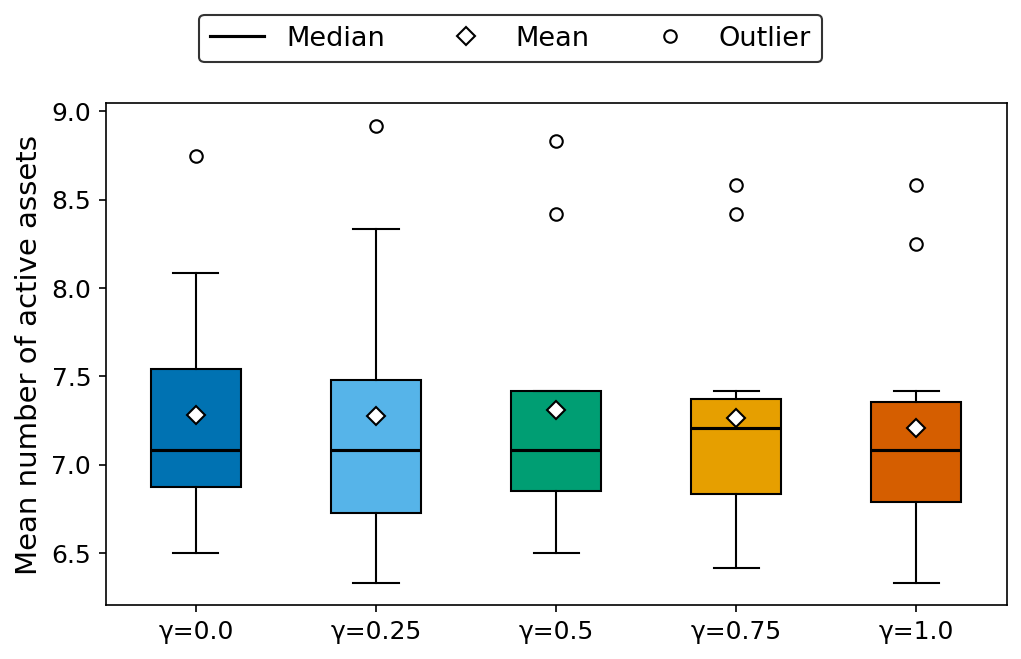

        mean  median    std
gamma                      
0.00   7.283   7.083  0.693
0.25   7.275   7.083  0.814
0.50   7.308   7.083  0.767
0.75   7.267   7.208  0.728
1.00   7.208   7.083  0.716

           rho(gamma, n_active)
data_seed                      
1                        -0.975
2                         0.632
3                         0.949
4                        -0.289
5                         0.580
6                        -1.000
7                        -0.359
8                        -0.667
9                         0.359
10                       -0.667

Mean rho: -0.144
Fraction with rho < 0: 0.6
Wilcoxon test rho != 0: statistic=19.500, p=0.4492


In [28]:
# FIGURE: Portfolio concentration (n_active) per gamma, distribution across data seeds
# Analogous to Lee et al. Table 1 — checks whether DFL concentrates portfolios as gamma increases

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 13})  # bump global font size for this figure

# Aggregate: mean number of active assets per (data_seed, gamma), averaged over 12 months
conc_df = (
    df.groupby(['data_seed', 'gamma'])['n_active']
    .mean()
    .reset_index()
    .rename(columns={'n_active': 'mean_n_active'})
)

fig, ax = plt.subplots(figsize=(7, 4))

conc_data = [conc_df.loc[conc_df['gamma'] == g, 'mean_n_active'].values for g in GAMMAS]
bp = ax.boxplot(
    conc_data, labels=[GSHORT[g] for g in GAMMAS], patch_artist=True,
    showmeans=True,
    medianprops=dict(color='black', linewidth=1.5),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=6),
)
for patch, g in zip(bp['boxes'], GAMMAS):
    patch.set_facecolor(COLORS[g])

ax.set_ylabel('Mean number of active assets', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
# ax.set_title('Portfolio concentration')

# --- Legend for median vs. mean vs. outlier ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1.5, label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markersize=6, label='Outlier'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.12), frameon=True, edgecolor='black', fontsize=13)

plt.tight_layout()
fig.subplots_adjust(top=0.95)
plt.savefig('final_portfolio_concentration.pdf', bbox_inches='tight')
plt.show()

# --- Numeric summary + rank correlation, same diagnostic as before ---
print(conc_df.groupby('gamma')['mean_n_active'].agg(['mean', 'median', 'std']).round(3))
print()

from scipy.stats import spearmanr, wilcoxon
corr_rows = []
for seed in range(1, 11):
    sub = conc_df[conc_df['data_seed'] == seed].sort_values('gamma')
    rho, p = spearmanr(sub['gamma'], sub['mean_n_active'])
    corr_rows.append({'data_seed': seed, 'rho(gamma, n_active)': rho})
conc_corr_df = pd.DataFrame(corr_rows).set_index('data_seed')
print(conc_corr_df.round(3).to_string())
print()
print("Mean rho:", conc_corr_df['rho(gamma, n_active)'].mean().round(3))
print("Fraction with rho < 0:", (conc_corr_df['rho(gamma, n_active)'] < 0).mean())
stat, p = wilcoxon(conc_corr_df['rho(gamma, n_active)'])
print(f"Wilcoxon test rho != 0: statistic={stat:.3f}, p={p:.4f}")

"Unlike Lee et al.'s unconstrained MVO setting, our CVaR constraint is binding in 90% of test instances. Prior work on CVaR-constrained portfolio optimization shows that a binding CVaR risk constraint tends to induce diversification rather than concentration (PORTFOLIO OPTIMIZATION WITH CONDITIONAL VALUE-AT-RISK OBJECTIVE AND CONSTRAINTS) — tightening the risk tolerance increased active asset count from a concentrated few to 15+. This suggests our CVaR constraint may be acting as a counterweight to DFL's theoretical tendency toward concentration (as shown for unconstrained MVO by Lee et al.), which would explain why our γ-driven concentration effect is muted: the CVaR constraint continually pulls portfolios toward diversification regardless of how much DFL 'wants' to concentrate them via γ."

## Up/Down prediction bias polarization

C:\Users\maxiw\AppData\Local\Temp\ipykernel_19140\561416930.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
C:\Users\maxiw\AppData\Local\Temp\ipykernel_19140\561416930.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


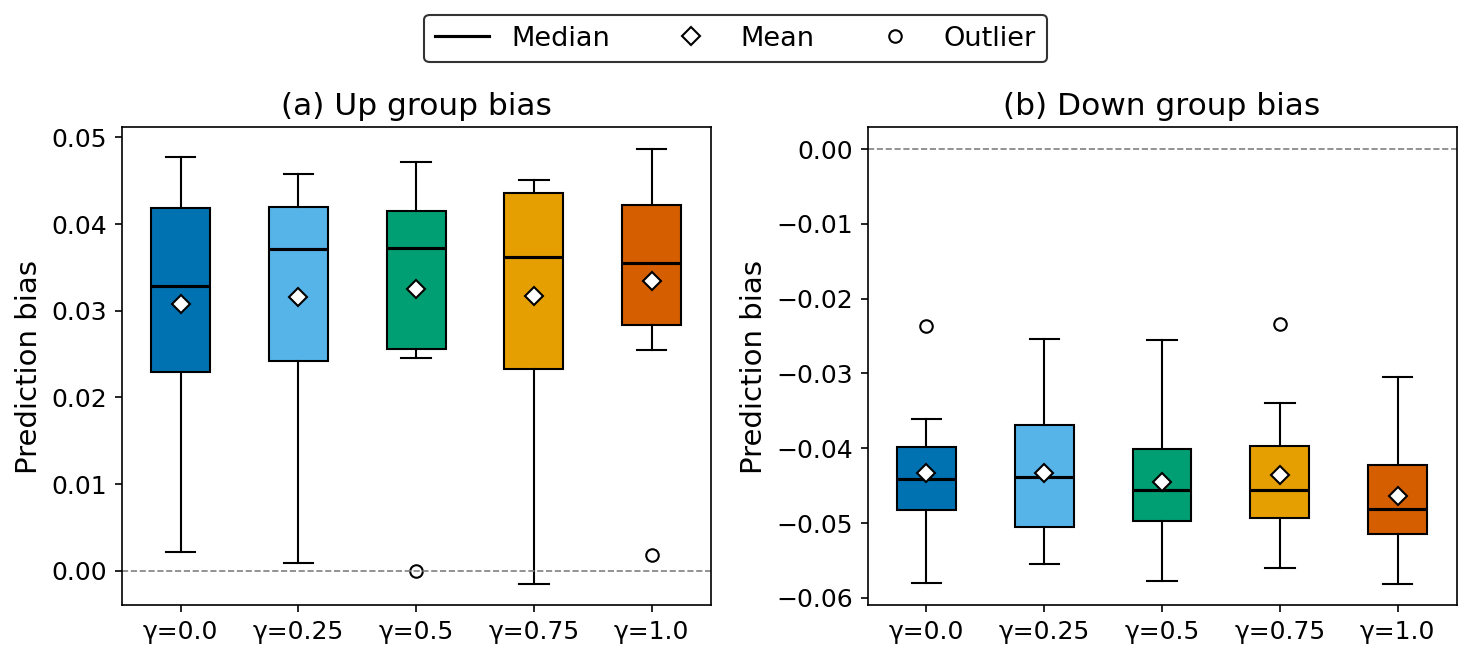

      up_bias                 down_bias                
         mean  median     std      mean  median     std
gamma                                                  
0.00   0.0308  0.0328  0.0140   -0.0433 -0.0441  0.0093
0.25   0.0316  0.0371  0.0146   -0.0433 -0.0439  0.0093
0.50   0.0325  0.0373  0.0141   -0.0445 -0.0456  0.0096
0.75   0.0317  0.0362  0.0148   -0.0436 -0.0456  0.0095
1.00   0.0334  0.0355  0.0136   -0.0464 -0.0482  0.0084


In [38]:
# FIGURE: Up/Down prediction bias per gamma, distribution across data seeds
# Replicates Lee et al. Figure 3 — classifies assets by predicted return sign,
# then tracks average bias (Y_hat - Y_true) within each group as gamma increases

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 13})  # bump global font size for this figure

def updown_bias(row):
    yhat = np.asarray(row['Y_hat_test'])
    y    = np.asarray(row['Y_test'])
    bias = yhat - y
    up_mask   = yhat > 0
    down_mask = ~up_mask
    up_bias   = bias[up_mask].mean()   if up_mask.sum()   > 0 else np.nan
    down_bias = bias[down_mask].mean() if down_mask.sum() > 0 else np.nan
    return pd.Series({'up_bias': up_bias, 'down_bias': down_bias})

# Row-level (per seed, gamma, test month) Up/Down bias
bias_rows = df.apply(updown_bias, axis=1)
df_bias = pd.concat([df[['data_seed', 'gamma']], bias_rows], axis=1)

# Aggregate per (data_seed, gamma), averaged over 12 test months — same
# aggregation level as sm_df, for consistency with the other boxplots
updown_df = (
    df_bias.groupby(['data_seed', 'gamma'])[['up_bias', 'down_bias']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- (a) Up group bias ---
up_data = [updown_df.loc[updown_df['gamma'] == g, 'up_bias'].values for g in GAMMAS]
bp1 = axes[0].boxplot(
    up_data, labels=[GSHORT[g] for g in GAMMAS], patch_artist=True,
    showmeans=True,
    medianprops=dict(color='black', linewidth=1.5),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=6),
)
for patch, g in zip(bp1['boxes'], GAMMAS):
    patch.set_facecolor(COLORS[g])
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Prediction bias', fontsize=14)
axes[0].set_title('(a) Up group bias', fontsize=15)
axes[0].tick_params(axis='both', labelsize=12)

# --- (b) Down group bias ---
down_data = [updown_df.loc[updown_df['gamma'] == g, 'down_bias'].values for g in GAMMAS]
bp2 = axes[1].boxplot(
    down_data, labels=[GSHORT[g] for g in GAMMAS], patch_artist=True,
    showmeans=True,
    medianprops=dict(color='black', linewidth=1.5),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=6),
)
for patch, g in zip(bp2['boxes'], GAMMAS):
    patch.set_facecolor(COLORS[g])
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Prediction bias', fontsize=14)
axes[1].set_title('(b) Down group bias', fontsize=15)
axes[1].tick_params(axis='both', labelsize=12)

# --- Shared legend ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1.5, label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markersize=6, label='Outlier'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.12), frameon=True, edgecolor='black', fontsize=13)

plt.tight_layout()
fig.subplots_adjust(top=0.91)
plt.savefig('final_updown_bias.pdf', bbox_inches='tight')
plt.show()

# --- Numeric summary ---
print(updown_df.groupby('gamma')[['up_bias', 'down_bias']].agg(['mean', 'median', 'std']).round(4))

In [11]:
# Compare distribution of true vs predicted returns
print("True:", pd.Series(np.concatenate(df['Y_test'])).describe())
print("Pred:", pd.Series(np.concatenate(df['Y_hat_test'])).describe())

True: count    9000.000000
mean        0.007463
std         0.082931
min        -0.370489
25%        -0.046336
50%         0.001327
75%         0.053960
max         0.332251
dtype: float64
Pred: count    9000.000000
mean        0.003273
std         0.044439
min        -0.163602
25%        -0.024884
50%         0.002676
75%         0.033718
max         0.161252
dtype: float64


## IN/OUT bias separation

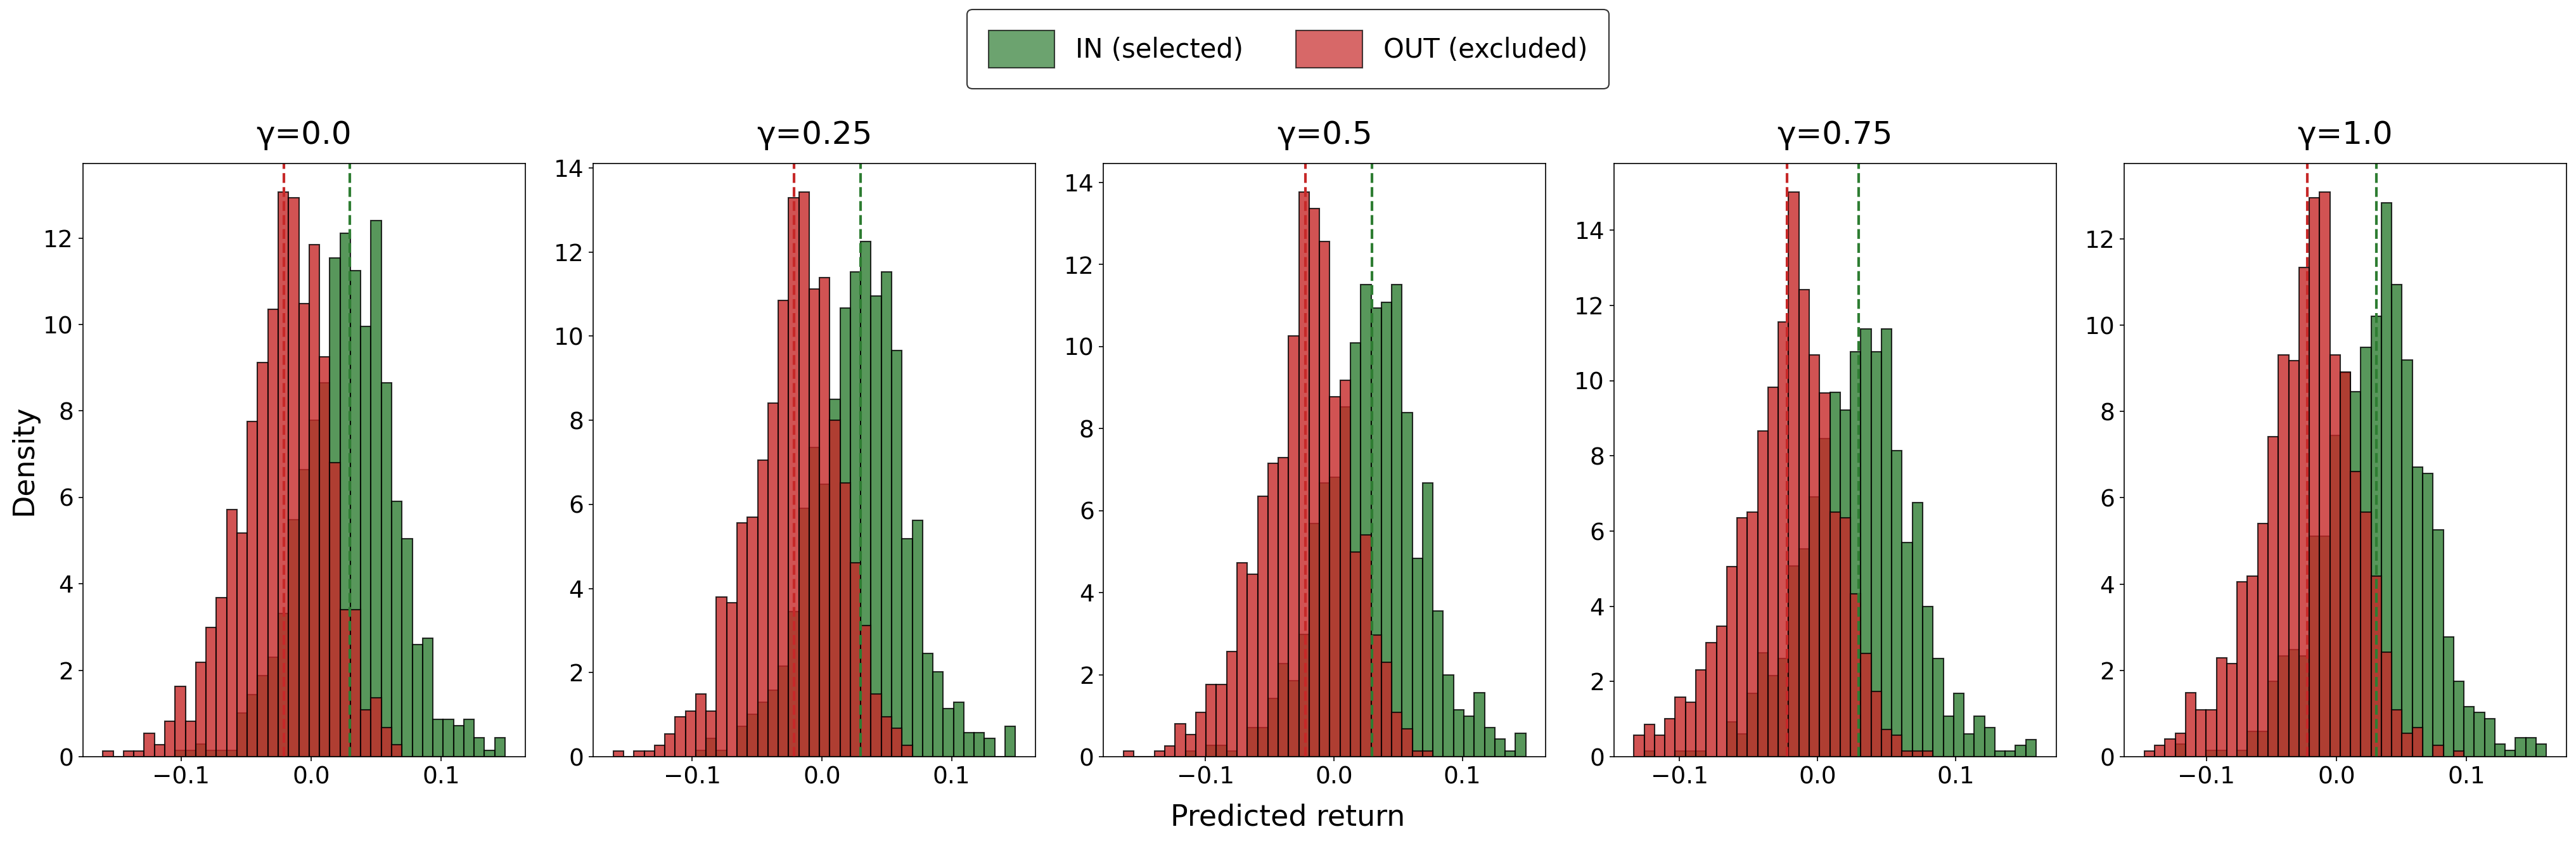

 gamma  in_mean  in_std  out_mean  out_std  separation
  0.00   0.0299  0.0359   -0.0211   0.0342      0.0510
  0.25   0.0297  0.0362   -0.0213   0.0343      0.0510
  0.50   0.0298  0.0380   -0.0223   0.0348      0.0522
  0.75   0.0299  0.0381   -0.0221   0.0348      0.0521
  1.00   0.0305  0.0388   -0.0223   0.0360      0.0529


In [56]:
# FIGURE: Predicted return distributions for IN/OUT portfolio groups, per gamma
# Replicates Lee et al. Figure 4 — histograms of predicted returns for assets
# selected into the portfolio (IN) vs excluded (OUT), pooled across all seeds/months

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20})  # large base size for print/thesis readability

IN_COLOR  = '#2E7D32'   # green, matches Lee et al.'s IN/green convention
OUT_COLOR = '#C62828'   # red,   matches Lee et al.'s OUT/red convention

def split_in_out(row):
    yhat = np.asarray(row['Y_hat_test'])
    mask = np.asarray(row['active_mask']).astype(bool)
    return yhat[mask], yhat[~mask]

fig, axes = plt.subplots(1, len(GAMMAS), figsize=(5.5 * len(GAMMAS), 8), sharey=False)

for ax, g in zip(axes, GAMMAS):
    sub = df[df['gamma'] == g]

    in_vals  = []
    out_vals = []
    for _, row in sub.iterrows():
        i, o = split_in_out(row)
        in_vals.append(i)
        out_vals.append(o)
    in_vals  = np.concatenate(in_vals)
    out_vals = np.concatenate(out_vals)

    bins = np.linspace(
        min(in_vals.min(), out_vals.min()),
        max(in_vals.max(), out_vals.max()),
        40
    )

    ax.hist(in_vals,  bins=bins, color=IN_COLOR,  edgecolor='black',
             alpha=0.8, label='IN',  density=True)
    ax.hist(out_vals, bins=bins, color=OUT_COLOR, edgecolor='black',
             alpha=0.8, label='OUT', density=True)

    ax.axvline(in_vals.mean(),  color=IN_COLOR,  linestyle='--', linewidth=2.0)
    ax.axvline(out_vals.mean(), color=OUT_COLOR, linestyle='--', linewidth=2.0)

    ax.set_title(GSHORT[g], fontsize=24, pad=15)
    ax.tick_params(axis='both', labelsize=18)

axes[0].set_ylabel('Density', fontsize=22)
fig.text(0.5, 0.03, 'Predicted return', ha='center', fontsize=22)

# --- Shared legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=IN_COLOR,  edgecolor='black', alpha=0.7, label='IN (selected)'),
    Patch(facecolor=OUT_COLOR, edgecolor='black', alpha=0.7, label='OUT (excluded)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.12), frameon=True, edgecolor='black',
           fontsize=20, handlelength=2.5, handleheight=1.8, borderpad=0.8)

plt.tight_layout()
fig.subplots_adjust(top=0.9, bottom=0.12)
plt.savefig('final_inout_distributions.pdf', bbox_inches='tight')
plt.show()

# --- Numeric summary: mean/std of IN vs OUT predicted returns per gamma ---
summary_rows = []
for g in GAMMAS:
    sub = df[df['gamma'] == g]
    in_vals, out_vals = [], []
    for _, row in sub.iterrows():
        i, o = split_in_out(row)
        in_vals.append(i)
        out_vals.append(o)
    in_vals  = np.concatenate(in_vals)
    out_vals = np.concatenate(out_vals)
    summary_rows.append({
        'gamma': g,
        'in_mean': in_vals.mean(), 'in_std': in_vals.std(),
        'out_mean': out_vals.mean(), 'out_std': out_vals.std(),
        'separation': in_vals.mean() - out_vals.mean(),
    })
print(pd.DataFrame(summary_rows).round(4).to_string(index=False))

"Unlike variance, which penalizes dispersion symmetrically and thus creates a genuine trade-off between an asset's predicted return and its full covariance contribution, CVaR is a one-sided risk measure that is indifferent to an asset's behavior outside the loss tail. Consequently, under CVaR-based selection, an asset with a high (or, given the VAR's overconfidence, artificially high) predicted return faces comparatively little resistance from the risk term unless its scenario-level tail losses are themselves problematic. This structural asymmetry — rather than an absence of the DFL mechanism — plausibly explains why portfolio composition in our setting is already strongly aligned with raw y_hat ranking at γ=0, leaving limited additional room for γ to further polarize selection, in contrast to the unconstrained mean-variance setting analyzed by Lee et al., where the full covariance matrix continuously trades off against predicted return."

Why log_scale parameter??

"Rather than adopting VAR-specific shrinkage techniques (e.g., Minnesota-prior Bayesian VAR), we opted for a minimal, targeted correction. Diagnostic analysis confirmed the fitted VAR was dynamically stable (companion-matrix eigenvalue modulus 0.816 < 1) and that its weight matrix did not pathologically amplify inputs (operator norm 0.83), ruling out coefficient-level instability as the cause of the observed prediction overshoot. Instead, the overshoot was attributable to a scale mismatch between standardized input features (norm ≈ √45) and an unnormalized target scale. We therefore introduced a single learnable output-scale parameter — conceptually related to post-hoc calibration techniques such as temperature scaling (Guo et al., 2017) and its regression analogue, std-scaling (Levi et al., 2022) — rather than a broader re-specification of the estimator, in order to correct the diagnosed cause precisely while preserving the model's affine structure and comparability across γ configurations."

## Structuring the "why it doesn't work" section

Ground each hypothesis in a specific plot/statistic you already have — don't let any of them float free as speculation:

**1. Training dynamics never diverge (primary, best-evidenced hypothesis).**
Your spo/mse ratio-tracking data shows MSE and SPO+ losses decreasing together, in near-lockstep, at every γ. Combined with `best_epoch` averaging ~2-3 out of a 10-epoch budget, this is consistent with training being interrupted while both losses are still in their shared, "reduce generic prediction error" phase — the point Lee et al.'s Σ⁻¹-tilting mechanism only becomes active once a model is fitting well enough for the *residual*, asset-specific trade-offs to matter. State this as your leading hypothesis, supported by the ratio data.

**2. CVaR's asymmetric risk structure narrows DFL's marginal role (theoretical, mechanistic hypothesis).**
Ground this in your derivation: CVaR only penalizes tail losses, so unlike variance, it doesn't create a full trade-off between predicted return and dispersion — an asset with high (possibly miscalibrated) predicted return faces little resistance unless its scenario-level tail losses are themselves bad. Your IN/OUT distribution plot (Image 6) directly supports this: separation between selected/excluded assets is **already strongly present at γ=0**, before DFL contributes anything — meaning selection is largely determined by raw predicted-return ranking regardless of training loss. This is your strongest *plot-grounded* mechanistic argument, and it's genuinely novel relative to Lee et al.'s unconstrained setting.

**3. The CVaR constraint (binding in 90% of cases) caps portfolio concentration independent of γ.**
Your flat `n_active` plot, combined with the binding-fraction check, supports this directly — concentration is governed by the constraint, not by γ, leaving DFL's usual "concentrate the portfolio" lever (per Lee et al.'s Table 1) largely unavailable in this setting.

## On the pre-scaling "directional but insignificant" result — needs one precision fix

Your intuition is right in spirit, but "pulled further away from MSE" isn't quite the precise mechanism — I'd sharpen it like this:

The SPO+ perturbation is `2ĉ − c*`. When `ĉ` is 5-7x the magnitude of `c*` (as it was pre-fix), this perturbation is **dominated by `ĉ`** — so `perturbed_c ≈ 2ĉ`, and since scaling a linear program's objective doesn't change its argmin, `perturbed_w` collapses to essentially **the portfolio implied purely by the model's own (miscalibrated) ranking**, rather than the theoretically-intended *blend* of predicted and true cost that gives SPO+ its subgradient validity. This means the gradient `2(oracle_w − perturbed_w)` under severe miscalibration was likely larger and noisier — not because it was more "correctly" DFL-like, but because the perturbation mechanism was effectively broken, producing a cruder, more aggressive training signal that happened to pull `W` further from the MSE solution, without that pull being grounded in SPO+'s actual theoretical construction.

Suggested phrasing:

> *"In an earlier version of this pipeline, prior to correcting a scale miscalibration in the return predictor, MSE and regret showed a directional but statistically insignificant γ-dependence. We hypothesize this stemmed not from a stronger genuine DFL signal, but from the SPO+ perturbation (2ĉ − c*) being dominated by the miscalibrated, oversized ĉ term — effectively decoupling the perturbed solution from the true cost c* and producing a cruder, higher-variance training signal that diverged further from MSE by construction, rather than through the mechanism SPO+ is designed to exploit. We did not have time to formally verify this mechanism (e.g., by directly comparing perturbed_w's dependence on ĉ vs. c* pre- and post-calibration) and present it as a hypothesis rather than a confirmed explanation."*

That last sentence matters — mark it explicitly as an untested hypothesis, not a finding. Given your time budget, that's the honest and defensible way to include it: it shows you thought carefully about the mechanism without overclaiming something you didn't verify.

"We deliberately retained the standard SPO+ formulation (perturbation 2ĉ − c) throughout, rather than introducing an additional tunable perturbation-strength hyperparameter. Our objective was to evaluate whether the DFL mechanism, as specified in the literature, transfers to a CVaR-constrained setting — not to optimize DFL's performance through additional hyperparameter search, which would fall outside the scope of this thesis and risk conflating a genuine test of the mechanism with a tuned, best-case result. We note, however, that the scale miscalibration in an earlier version of our pipeline (Section X) had the incidental effect of amplifying the SPO+ perturbation beyond its theoretical specification; whether a deliberately controlled version of such amplification improves decision quality is a question we leave to future work."*

# Diagnosing SPO+ Behavior

In [ ]:
# SPO+ Diagnostic Analysis
# Loads the instrumented single-(seed, test_index) run across
# all gamma values and produces the diagnostic plots/tables.

In [39]:
with open("results_spo+_diagnosis_checkpoint.pkl", "rb") as f:
    diag_results = pickle.load(f)

with open("diagnostics_checkpoint.pkl", "rb") as f:
    diagnostics = pickle.load(f)   # dict: {gamma: diag_df}

gammas_available = sorted(diagnostics.keys())
print("Gammas available in this diagnostic run:", gammas_available)

Gammas available in this diagnostic run: [0, 0.25, 0.5, 0.75, 1.0]


In [40]:
# Batch-level aggregation (exact, given per-sample mean-reduced losses)
batch_diag = {}
for g, d in diagnostics.items():
    bd = d.groupby(['epoch', 'batch']).agg(
        vertex_match_rate=('vertex_match', 'mean'),
        spo_grad_norm_raw=('spo_grad_norm_raw', 'mean'),
        mse_grad_norm_raw=('mse_grad_norm_raw', 'mean'),
        spo_grad_norm_normed=('spo_grad_norm_normed', 'mean'),
        mse_grad_norm_normed=('mse_grad_norm_normed', 'mean'),
        spo_grad_norm_weighted=('spo_grad_norm_weighted', 'mean'),
        mse_grad_norm_weighted=('mse_grad_norm_weighted', 'mean'),
        cosine_similarity=('cosine_similarity', 'mean'),
    ).reset_index()
    bd['step'] = range(len(bd))  # global step index across epochs, for x-axis
    batch_diag[g] = bd

In [41]:
# 1. Vertex coincidence rate

print("\n=== Vertex coincidence rate (fraction of steps with oracle_w == perturbed_w) ===")
vertex_summary = pd.DataFrame([
    {'gamma': g, 'vertex_coincidence_rate': d['vertex_match'].mean(), 'n_steps': len(d)}
    for g, d in diagnostics.items()
])
print(vertex_summary.to_string(index=False))

# fig, ax = plt.subplots(figsize=(6, 4))
# ax.bar([str(g) for g in vertex_summary['gamma']], vertex_summary['vertex_coincidence_rate'],
#        color='#009E73', edgecolor='black')
# ax.set_ylabel('Vertex coincidence rate')
# ax.set_xlabel('γ')
# ax.set_ylim(0, 1)
# ax.set_title('Fraction of training steps with oracle_w = perturbed_w\n(zero SPO+ subgradient)')
# plt.tight_layout()
# plt.savefig('diag_vertex_coincidence.pdf', bbox_inches='tight')
# plt.show()


=== Vertex coincidence rate (fraction of steps with oracle_w == perturbed_w) ===
 gamma  vertex_coincidence_rate  n_steps
  0.00                      0.0     1395
  0.25                      0.0     2790
  0.50                      0.0     1395
  0.75                      0.0     1116
  1.00                      0.0     1116


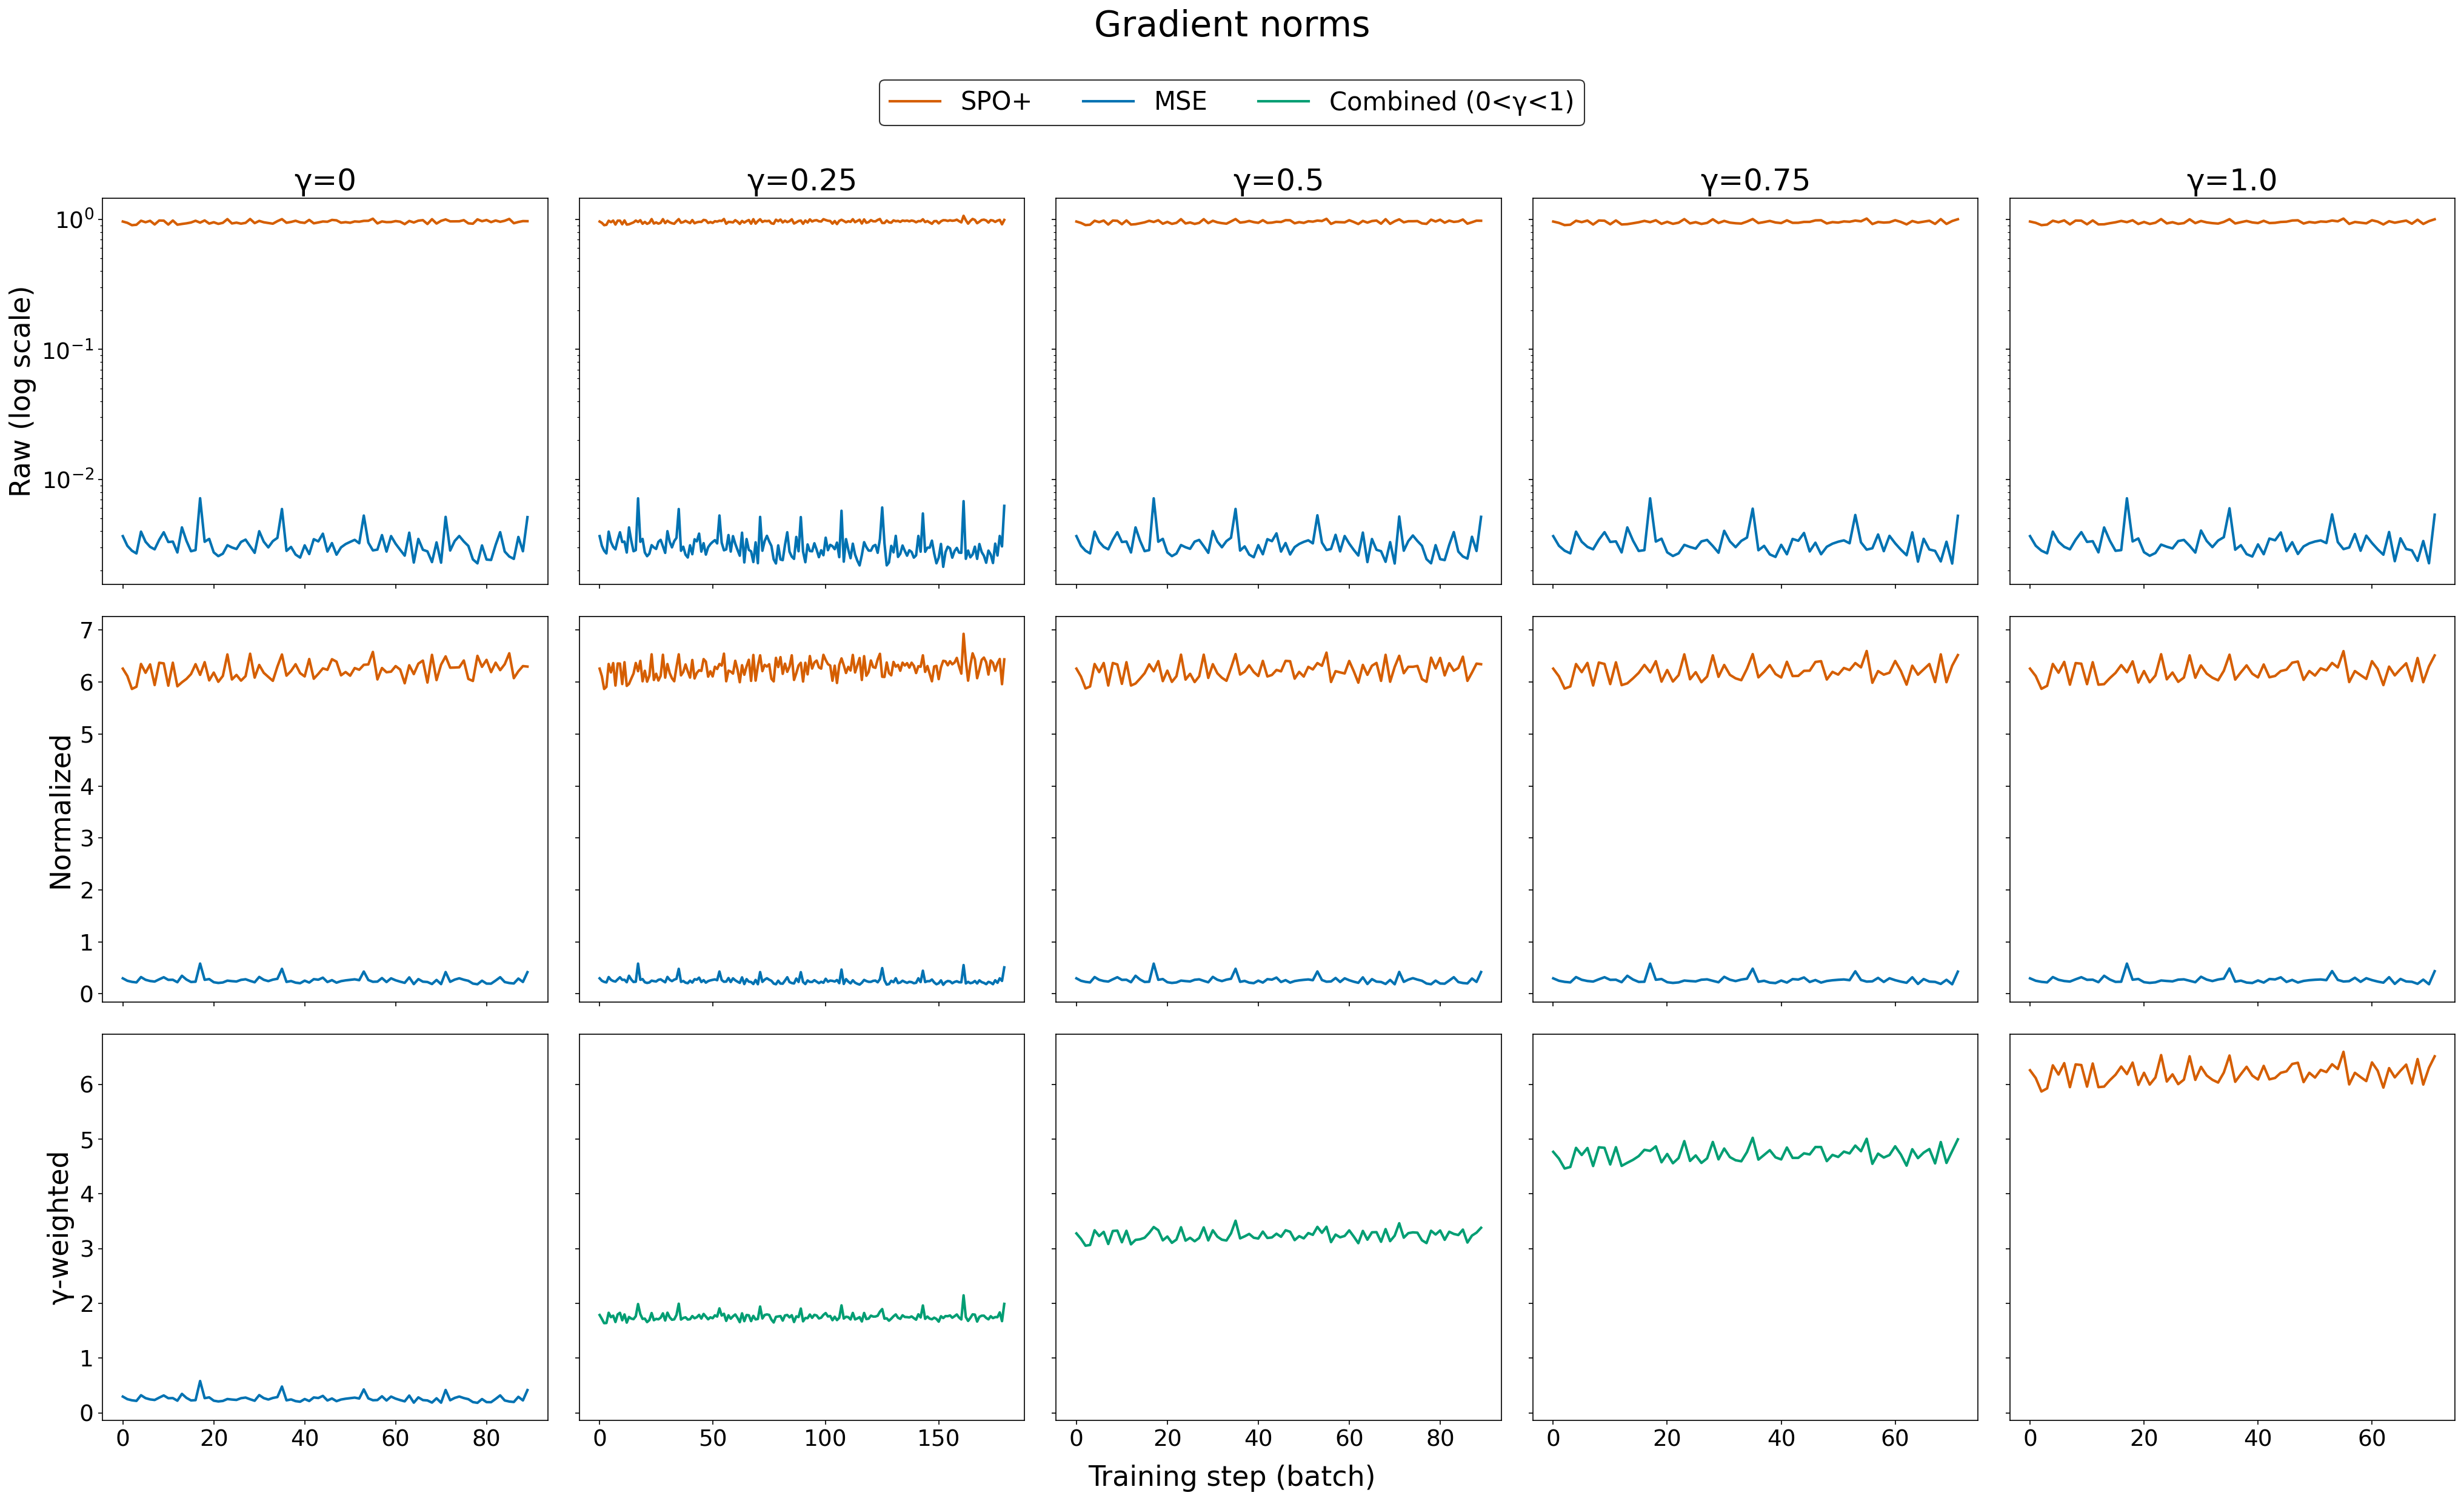

In [48]:
# 2. Gradient norms over training (raw, normalized, weighted)

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20})  # large base size for print/thesis readability

n_gammas = len(gammas_available)
fig, axes = plt.subplots(3, n_gammas, figsize=(5.5 * n_gammas, 16), sharex='col', sharey='row')
if n_gammas == 1:
    axes = axes.reshape(3, 1)

SPO_COLOR = '#D55E00'
MSE_COLOR = '#0072B2'
MIXED_COLOR = '#009E73'   # new color for intermediate gamma (0 < gamma < 1)

for col, g in enumerate(gammas_available):
    bd = batch_diag[g]

    # Row 0: Raw
    ax = axes[0, col]
    ax.plot(bd['step'], bd['spo_grad_norm_raw'], color=SPO_COLOR, linewidth=2.0)
    ax.plot(bd['step'], bd['mse_grad_norm_raw'], color=MSE_COLOR, linewidth=2.0)
    ax.set_title(f'γ={g}', fontsize=24)
    ax.set_yscale('log')
    ax.tick_params(axis='both', labelsize=18)
    if col == 0:
        ax.set_ylabel('Raw (log scale)', fontsize=22)

    # Row 1: Normalized
    ax = axes[1, col]
    ax.plot(bd['step'], bd['spo_grad_norm_normed'], color=SPO_COLOR, linewidth=2.0)
    ax.plot(bd['step'], bd['mse_grad_norm_normed'], color=MSE_COLOR, linewidth=2.0)
    # ax.set_yscale('log')
    ax.tick_params(axis='both', labelsize=18)
    if col == 0:
        ax.set_ylabel('Normalized', fontsize=22)

    # Row 2: gamma-weighted, aggregated (sum of both contributions)
    ax = axes[2, col]
    aggregate = bd['spo_grad_norm_weighted'] + bd['mse_grad_norm_weighted']
    if g == 0:
        agg_color = MSE_COLOR       # weighted SPO+ term is exactly 0
    elif g == 1.0 or g == 1:
        agg_color = SPO_COLOR       # weighted MSE term is exactly 0
    else:
        agg_color = MIXED_COLOR
    ax.plot(bd['step'], aggregate, color=agg_color, linewidth=2.0)
    # ax.set_yscale('log')
    ax.tick_params(axis='both', labelsize=18)
    if col == 0:
        ax.set_ylabel('γ-weighted', fontsize=22)

fig.suptitle('Gradient norms', fontsize=28, y=1.03)
fig.text(0.5, 0.015, 'Training step (batch)', ha='center', fontsize=22)

# Shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=SPO_COLOR, linewidth=2.0, label='SPO+'),
    Line2D([0], [0], color=MSE_COLOR, linewidth=2.0, label='MSE'),
    Line2D([0], [0], color=MIXED_COLOR, linewidth=2.0, label='Combined (0<γ<1)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 0.99), frameon=True, edgecolor='black', fontsize=20)

plt.tight_layout()
fig.subplots_adjust(top=0.90, bottom=0.06)
plt.savefig('diag_gradient_norms.pdf', bbox_inches='tight')
plt.show()

"We further find that our loss normalization procedure, which matches SPO+ and MSE loss values at initialization, does not equalize their gradient magnitudes: SPO+'s raw gradient norm remains roughly two orders of magnitude larger than MSE's throughout training (Figure X), even after normalization. This is because SPO+'s loss is constructed from portfolio-weight dot products bounded by the CVaR-LP's feasible region, while MSE is a squared prediction error — matched loss values do not imply matched gradients. This provides a more precise mechanistic account of the SPO+ gradient dominance reported in Section Y, and suggests that gradient-based (rather than loss-based) normalization is a more principled approach for future implementations of this combined-loss framework."

Lee et al. propose: For numerical experiments, the MSE loss may be multiplied by a positive scalar to match the scale of MVO loss.

But this does not suffice for SPO+ in an LP.

### Loss Normalization Under a Constrained LP: A Limitation of Value-Based Scaling

Lee et al. (2025) note that, for numerical purposes, the MSE loss may be
multiplied by a positive scalar to match the scale of the MVO loss. In their
unconstrained MVO setting, this is a reasonable heuristic: the optimal
portfolio $w^*(\hat\mu) = \frac{1}{2\lambda}\Sigma^{-1}\hat\mu$ (their Eq. 6)
is a smooth, closed-form linear function of $\hat\mu$, so the MVO loss
responds to prediction error in a continuous, MSE-like manner. Matching loss
*values* at initialization is therefore a reasonable proxy for matching
*gradients*, since both losses are smooth functions of $\hat\mu$ with
comparably well-behaved derivatives.

This assumption does not transfer to our CVaR-constrained setting. The
optimal portfolio $w^*(c)$ of the CVaR-LP is a **piecewise-constant**
function of the cost vector $c$: it changes only at transitions between
vertices of the feasible polytope defined by the weight cap and CVaR
constraint, and is otherwise locally constant. The SPO+ subgradient,

$$
\frac{\partial \mathcal{L}_{\text{SPO+}}}{\partial \hat\mu} =
2\left(w^*(c^*) - w^*(2\hat c - c^*)\right),
$$

is therefore governed by the *distance between vertices* the perturbed and
oracle problems happen to land on, rather than by the magnitude of the
prediction residual $(\hat\mu - \mu^*)$ itself. Two predictions with very
different residual magnitudes can produce the same gradient if they induce
the same vertex transition, and conversely a small change in $\hat\mu$ can
produce a large gradient if it crosses a vertex boundary. This is
fundamentally different from MSE's smooth, residual-proportional gradient,
and from the smooth MVO loss Lee et al. analyze.

**Empirical confirmation.** Our gradient diagnostics (Section X) show this
directly: even after value-based normalization, SPO+'s gradient norm exceeds
MSE's by roughly two orders of magnitude throughout training, and this gap
does not close over training progress (Figure X). Value-based normalization
equalizes the two losses at a single point (their magnitude at
initialization) but says nothing about their derivatives when one loss is
smooth and the other is a piecewise-constant, combinatorial function of the
optimization variables — an assumption Lee et al.'s heuristic implicitly
relies on, but which breaks down once the downstream decision problem
involves a genuine constrained LP with a vertex-based solution map.

**Implication.** A more principled alternative for this setting would be
*gradient-based* normalization — matching gradient norms directly at
initialization, rather than loss values — which we did not implement given
time constraints (see Limitations, Section Y). We flag this as a specific,
generalizable methodological finding: value-based loss normalization, as
proposed for unconstrained MVO, is insufficient once decision-focused
learning is applied to a constrained LP with a non-smooth solution map, and
future implementations of DFL under such constraints should normalize on
gradients rather than loss magnitudes.

One might consider addressing this by rescaling each step's SPO+ gradient to unit norm during the backward pass, but this would discard the magnitude information that makes the SPO+ subgradient a valid indicator of local vertex displacement, effectively replacing the theoretically-grounded SPO+ surrogate with an ad hoc, direction-only training signal. A more principled alternative, consistent with Lee et al.'s original heuristic, is to compute a single, aggregate gradient-norm scale at initialization — analogous to their loss-value normalization but computed on gradients rather than losses — and apply it as a constant divisor throughout training, which we did not implement given time constraints.

"Because model initialization and batch ordering are held fixed across γ (Section X) to isolate the effect of the loss composition, gradient norms computed on the same underlying batch of training instances are naturally similar across γ configurations

Gradient clipping (max norm 1.0) also serves a genuine stabilizing role.
Because SPO+'s gradient is tied to discrete vertex transitions of the
CVaR-LP's feasible region rather than a smooth residual, its magnitude can
vary sharply between batches; clipping bounds the resulting step size and
prevents any single such jump from producing a disproportionately large
update. It further equalizes step size *across* γ: without clipping,
γ=0.25 would take steps roughly six times smaller than γ=1.0 purely
because SPO+'s pre-clip norm so exceeds MSE's (Figure X), not because
higher γ warrants a larger correction. This benefit comes at the cost
established above: since post-clip norm is pinned at exactly 1.0 whenever
the threshold is exceeded, the batch-to-batch magnitude differences that
might otherwise signal which training instances carry more informative
SPO+ gradients are discarded for every γ>0. Clipping thus trades
instance-level magnitude information for stable, cross-γ-comparable step
sizes -- a standard and defensible choice given SPO+'s non-smooth loss
surface, but one with a real cost to the granularity of the training
signal.

C:\Users\maxiw\AppData\Local\Temp\ipykernel_19140\4193346349.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


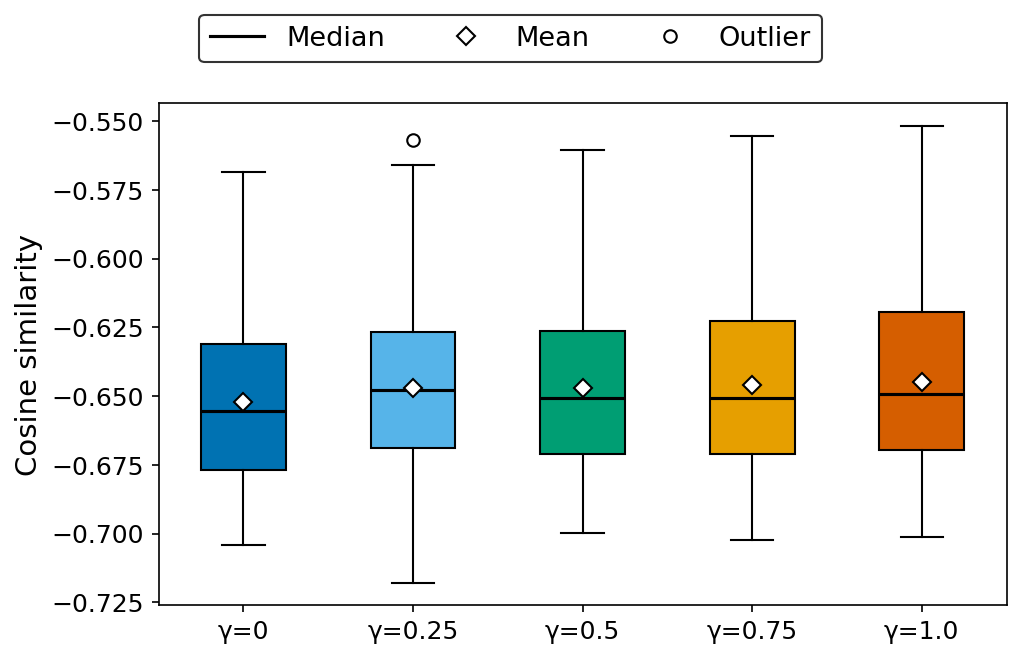


=== Cosine similarity summary ===
γ=0: mean=-0.652, median=-0.656, fraction negative=1.000, fraction NaN (zero SPO+ grad)=0.000
γ=0.25: mean=-0.647, median=-0.648, fraction negative=1.000, fraction NaN (zero SPO+ grad)=0.000
γ=0.5: mean=-0.647, median=-0.651, fraction negative=1.000, fraction NaN (zero SPO+ grad)=0.000
γ=0.75: mean=-0.646, median=-0.651, fraction negative=1.000, fraction NaN (zero SPO+ grad)=0.000
γ=1.0: mean=-0.645, median=-0.649, fraction negative=1.000, fraction NaN (zero SPO+ grad)=0.000


In [51]:
# 3. Cosine similarity between SPO+ and MSE gradient directions

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 13})  # match font size used in other figures

fig, ax = plt.subplots(figsize=(7, 4))

cos_data = [batch_diag[g]['cosine_similarity'].dropna().values for g in gammas_available]
bp = ax.boxplot(
    cos_data, labels=[f'γ={g}' for g in gammas_available], patch_artist=True,
    showmeans=True,
    medianprops=dict(color='black', linewidth=1.5),
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=6),
)
for patch, g in zip(bp['boxes'], gammas_available):
    patch.set_facecolor(COLORS[g])

# ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylabel('Cosine similarity', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
# ax.set_title('Batch-level gradient direction agreement')

# Shared legend
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1.5, label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markersize=6, label='Outlier'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.12), frameon=True, edgecolor='black', fontsize=13)

plt.tight_layout()
fig.subplots_adjust(top=0.95)
plt.savefig('diag_cosine_similarity.pdf', bbox_inches='tight')
plt.show()

print("\n=== Cosine similarity summary ===")
for g in gammas_available:
    d = batch_diag[g]['cosine_similarity']
    print(f"γ={g}: mean={d.mean():.3f}, median={d.median():.3f}, "
          f"fraction negative={ (d < 0).mean():.3f}, "
          f"fraction NaN (zero SPO+ grad)={ (batch_diag[g]['cosine_similarity'].isna()).mean():.3f}")

### Gradient Direction Agreement Across γ

Across all five γ configurations, the cosine similarity between the SPO+
and MSE gradients is consistently negative, with medians clustered tightly
around −0.65 (interquartile ranges roughly −0.62 to −0.68) regardless of
γ. Notably, this holds even at γ=0 and γ=1.0, where only one of the two
losses actually enters the training objective — the "unused" gradient
was computed purely for diagnostic purposes at each step. The near-identical
distributions across all γ indicate that the opposition between SPO+'s and
MSE's gradient directions is a stable property of this predictor and
decision problem, rather than something that emerges from, or is amplified
by, training under a particular loss composition.

This provides direct evidence against the hypothesis that DFL fails to
influence the trained model due to a weak or absent training signal: at
every γ, SPO+ produces a gradient that not only has substantially larger
magnitude than MSE's (Figure X), but also points in a systematically
different — and specifically opposing — direction. The mechanism reducing
regret is, on average, close to the opposite of the mechanism reducing
squared prediction error for this CVaR-constrained decision problem.

That this systematic, strong training signal does not translate into
γ-dependent differences in test-set outcomes (Section Y) therefore suggests
that DFL training *does* meaningfully alter the model on the training data,
but the resulting adjustment does not generalize to unseen test months. With
only 279 training observations available per fold, SPO+'s gradient — driven
by discrete vertex-to-vertex displacements of the CVaR-LP's feasible region
rather than a smooth residual — is plausibly well-suited to fitting the
particular scenario structure and vertex transitions realized in the
training sample, without this adjustment reflecting a decision-relevant
pattern that transfers out of sample. This interpretation is consistent
with early stopping consistently triggering after only two to three epochs
(Table X), coinciding with the point at which validation regret ceased to
improve despite continued, substantial gradient activity in training. We
therefore attribute the muted γ-dependence in final outcomes primarily to a
generalization gap rather than to an absence or weakness of the underlying
DFL training signal.

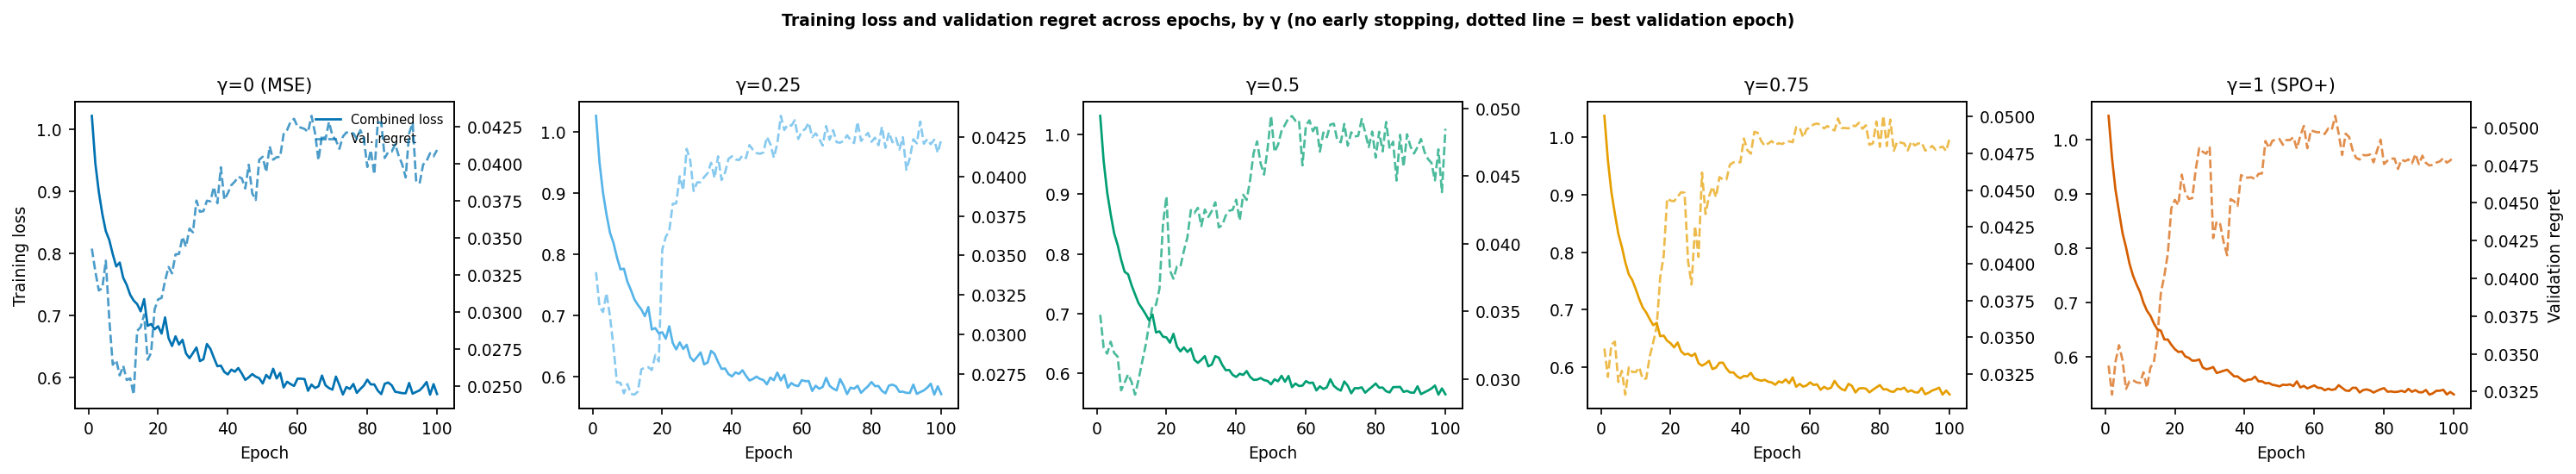

In [5]:
# 4. Training loss curves without early stopping

# Match existing plot style
GAMMAS  = [0.0, 0.25, 0.5, 0.75, 1.0]
GLABELS = {0.0: 'γ=0 (MSE)', 0.25: 'γ=0.25', 0.5: 'γ=0.5',
           0.75: 'γ=0.75',   1.0: 'γ=1 (SPO+)'}
COLORS  = {0.0: '#0072B2', 0.25: '#56B4E9', 0.5: '#009E73',
           0.75: '#E69F00', 1.0: '#D55E00'}

plt.rcParams.update({
    'font.size': 9, 'axes.titlesize': 10,
    'axes.labelsize': 9, 'figure.dpi': 150,
})

with open("results_spo+_diagnosis_100epochs.pkl", "rb") as f:
    diag_results = pickle.load(f)

# index results by gamma (one run per gamma for this diagnostic fold)
results_by_gamma = {r['gamma']: r for r in diag_results}

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), sharey=False)

for ax, g in zip(axes, GAMMAS):
    r = results_by_gamma[g]
    history = r['history']

    combined_loss = history['combined_loss']
    val_regret    = history['val_regret']
    best_epoch    = history['best_epoch']
    epochs        = range(1, len(combined_loss) + 1)

    color = COLORS[g]

    # left axis: training loss
    ax.plot(epochs, combined_loss, color=color, linewidth=1.3, label='Combined loss')
    ax.set_xlabel('Epoch')
    if ax is axes[0]:
        ax.set_ylabel('Training loss')

    # right axis: validation regret
    ax2 = ax.twinx()
    ax2.plot(epochs, val_regret, color=color, linewidth=1.3,
              linestyle='--', alpha=0.7, label='Val. regret')
    if ax is axes[-1]:
        ax2.set_ylabel('Validation regret')

    # mark best epoch (lowest validation regret)
    if best_epoch is not None:
        ax.axvline(best_epoch, color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(GLABELS[g])

    # combined legend (only once, on first subplot)
    if ax is axes[0]:
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2,
                  loc='upper right', fontsize=7, frameon=False)

fig.suptitle(
    'Training loss and validation regret across epochs, by γ '
    '(no early stopping, dotted line = best validation epoch)',
    fontsize=9, fontweight='bold', y=1.03,
)

plt.tight_layout()
plt.savefig('final_training_curves.pdf', bbox_inches='tight')
plt.show()